# E-commerce Business Analysis: Sales, Customers, Operations & Profit Insights

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df=pd.read_excel("C:/Users/CompuMisr/Downloads/store.xlsx")

In [6]:
pd.set_option('display.max_columns', None)

In [10]:
df.head(3)

,Order_ID,Customer_ID,Customer_Name,Gender,Age,Marital_Status,Education,Occupation,Annual_Income,City,Region,Join_Date,Product_ID,Product_Name,Category,Sub_Category,Brand,Quantity,Unit_Price,Discount_Percent,Tax,Shipping_Cost,Payment_Method,Order_Date,Delivery_Date,Delivery_Days,Customer_Rating,Return_Status,Promotion_Code,Total_Sales,Profit,Customer_Satisfaction,Warehouse,Sales_Channel,Order_Status
0,100000,C00000,Ahmed,Male,45,Single,Master,Engineer,48088,Mansoura,North,2024-12-11,P896,Product_163,Sports,Sub_1,Samsung,3,4450.67,29,20,27,Cash,2024-11-13,2025-11-02,9,1,No,PROMO41,9479.93,2435.00,2,W5,Website,Shipped
1,100001,C00001,Mariam,Male,47,Single,High School,Accountant,22775,Alexandria,East,2025-03-06,P239,Product_152,Clothing,Sub_6,Samsung,4,4905.51,24,17,76,Mastercard,2025-03-08,2024-11-08,10,2,Yes,PROMO42,14912.75,3334.36,10,W3,Store,Delivered
2,100002,C00002,Youssef,Female,58,Married,Bachelor,Engineer,6034,Aswan,South,2024-03-18,P691,Product_162,Beauty,Sub_1,Dell,5,1965.00,30,10,77,Mastercard,2024-06-15,2025-11-26,5,5,Yes,PROMO46,6877.50,1325.06,1,W1,Website,Delivered


# Cleaning The Data

In [36]:
!pip install gender-guesser

In [37]:
import gender_guesser.detector as gender

d = gender.Detector(case_sensitive=False)


def fix_gender(row):
    name = str(row["Customer_Name"]).split()[0]
    guess = d.get_gender(name)
    if guess in ["male", "mostly_male"]:
        return "Male"
    if guess in ["female", "mostly_female"]:
        return "Female"
    return row["Gender"]


df["Gender"] = df.apply(fix_gender, axis=1)

In [38]:
df[["Customer_Name", "Gender"]].head(10)

,Customer_Name,Gender
0,Ahmed,Male
1,Mariam,Female
2,Youssef,Male
3,Omar,Male
4,Omar,Male
5,Nour,Female
6,Mona,Female
7,Sara,Female
8,Mariam,Female
9,Mariam,Female


# Question 1:What are the total sales,total profit,total order?

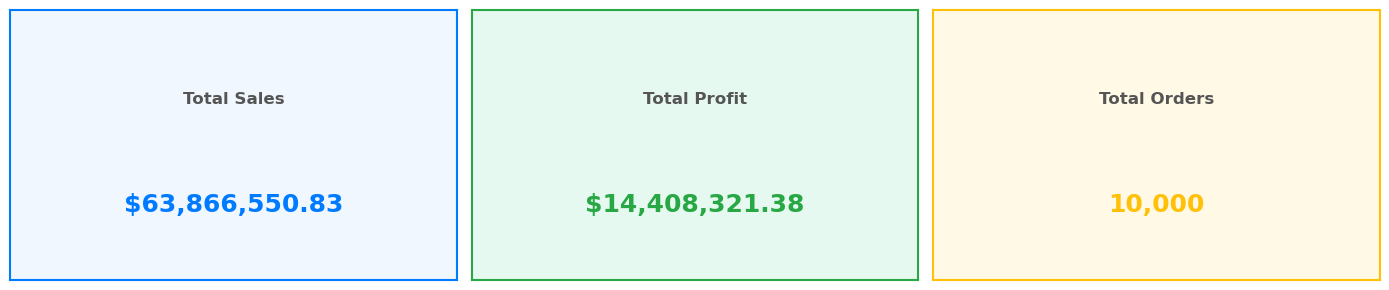

In [12]:
sales_text = f"${df['Total_Sales'].sum():,.2f}"
profit_text = f"${df['Profit'].sum():,.2f}"
orders_text = f"{len(df):,}"

fig, axs = plt.subplots(1, 3, figsize=(14, 3))

axs[0].text(0.5, 0.65, 'Total Sales', fontsize=12, ha='center', color='#555555', weight='bold')
axs[0].text(0.5, 0.25, sales_text, fontsize=18, ha='center', color='#007bff', weight='bold')
axs[0].set_facecolor('#f0f7ff')
for spine in axs[0].spines.values():
    spine.set_color('#007bff')
    spine.set_linewidth(1.5)

axs[1].text(0.5, 0.65, 'Total Profit', fontsize=12, ha='center', color='#555555', weight='bold')
axs[1].text(0.5, 0.25, profit_text, fontsize=18, ha='center', color='#28a745', weight='bold')
axs[1].set_facecolor('#e6f9f0')
for spine in axs[1].spines.values():
    spine.set_color('#28a745')
    spine.set_linewidth(1.5)

axs[2].text(0.5, 0.65, 'Total Orders', fontsize=12, ha='center', color='#555555', weight='bold')
axs[2].text(0.5, 0.25, orders_text, fontsize=18, ha='center', color='#ffc107', weight='bold')
axs[2].set_facecolor('#fff9e6')
for spine in axs[2].spines.values():
    spine.set_color('#ffc107')
    spine.set_linewidth(1.5)

for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()



## 💡 Business Insight
### ✔ The store achieved strong overall sales performance during the analyzed period.
### ✔ Positive profitability indicates healthy business operations.
### ✔ Consistent order volume reflects stable customer demand.

# Question 2: How do Sales and Profit change across months? Is there a clear peak season?

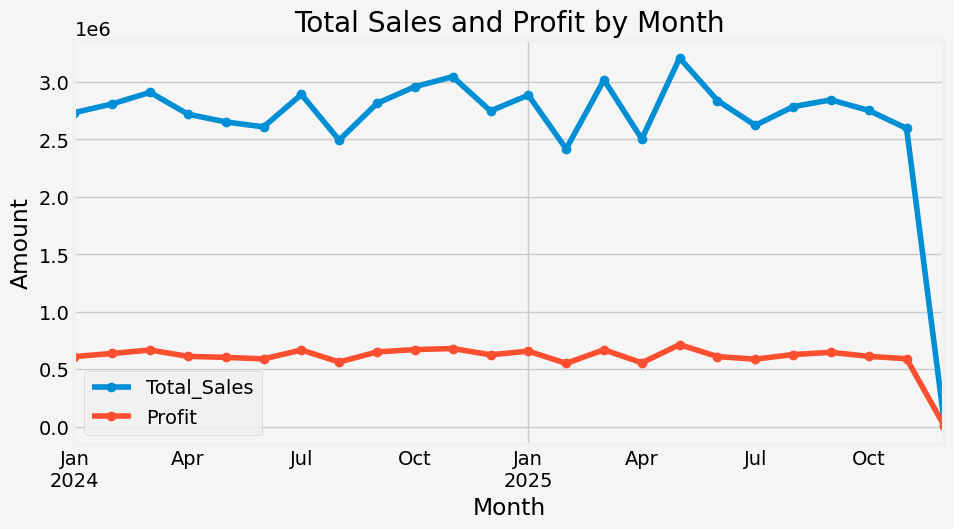

In [20]:
df["Order_Date"] = pd.to_datetime(df["Order_Date"])

monthly_sales = df.groupby(
    df["Order_Date"].dt.to_period("M")
)[["Total_Sales", "Profit"]].sum()

monthly_sales.plot(kind="line", marker="o", figsize=(10,5))

plt.title("Total Sales and Profit by Month")
plt.xlabel("Month")
plt.ylabel("Amount")

plt.gca().set_facecolor("#F5F5F5")
plt.gcf().set_facecolor("#F5F5F5")

plt.show()

## 💡 Business Insight
### ✔ Sales and profit fluctuated across different months.
### ✔ Certain periods generated significantly higher revenue.
### ✔ Seasonal patterns can be observed in customer purchasing behavior.

# Question 3: Does increasing discounts lead to higher profits or losses?

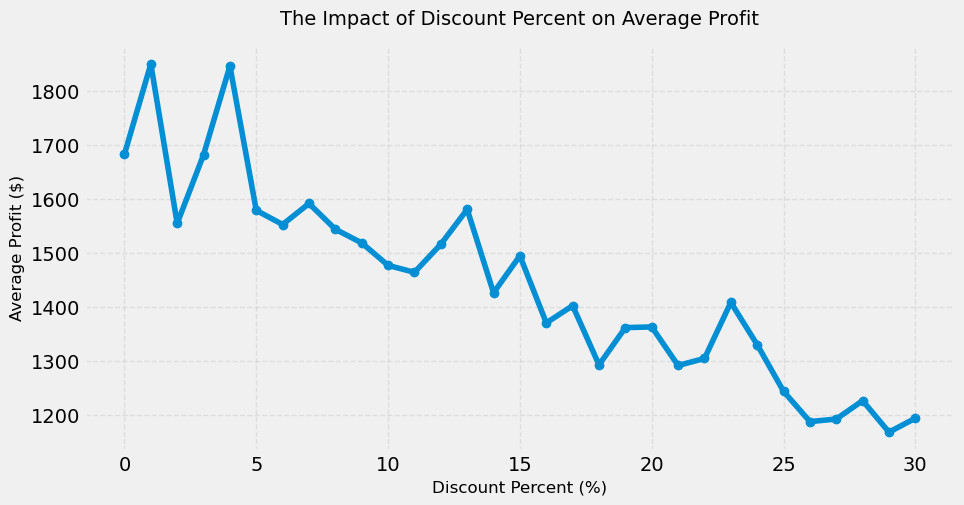

In [27]:
discount_data = (
    df.groupby("Discount_Percent")["Profit"].mean().reset_index().sort_values("Discount_Percent")
)

discount_data.plot(
    x="Discount_Percent", y="Profit", kind="line", marker="o", figsize=(10, 5), legend=False
)

plt.title("The Impact of Discount Percent on Average Profit", fontsize=14, pad=15)
plt.xlabel("Discount Percent (%)", fontsize=12)
plt.ylabel("Average Profit ($)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()

## 💡 Business Insight
### ✔ Higher discounts do not necessarily result in higher profits.
### ✔ Excessive discounts can reduce overall profit margins.
### ✔ Profitability depends on maintaining a balance between sales and discounts.

# Question 4: Which discount categories achieve the highest average profit

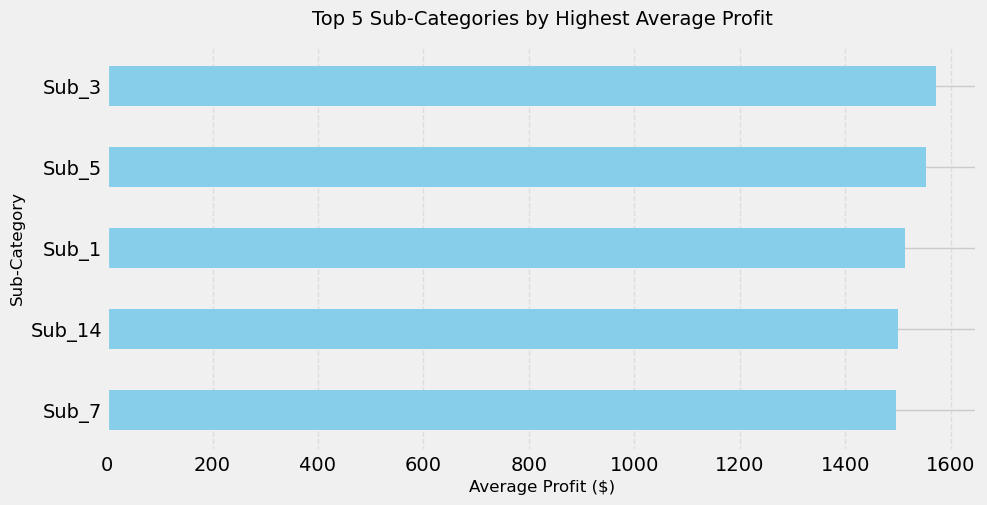

In [52]:
sub_category_profit = (
    df.groupby("Sub_Category")["Profit"]
    .mean()
    .reset_index()
    .sort_values("Profit", ascending=True)
)

sub_category_profit.tail(5).plot(
    x="Sub_Category", y="Profit", kind="barh", figsize=(10, 5), color="skyblue", legend=False
)

plt.title("Top 5 Sub-Categories by Highest Average Profit", fontsize=14, pad=15)
plt.xlabel("Average Profit ($)", fontsize=12)
plt.ylabel("Sub-Category", fontsize=12)
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.show()

## 💡 Business Insight
### ✔ Moderate discount levels generated the highest average profit.
### ✔ Extremely high discounts negatively affected profitability.
### ✔ Optimized discount strategies deliver better financial results

# Question 5:Who are the top 5 customers by total spending?

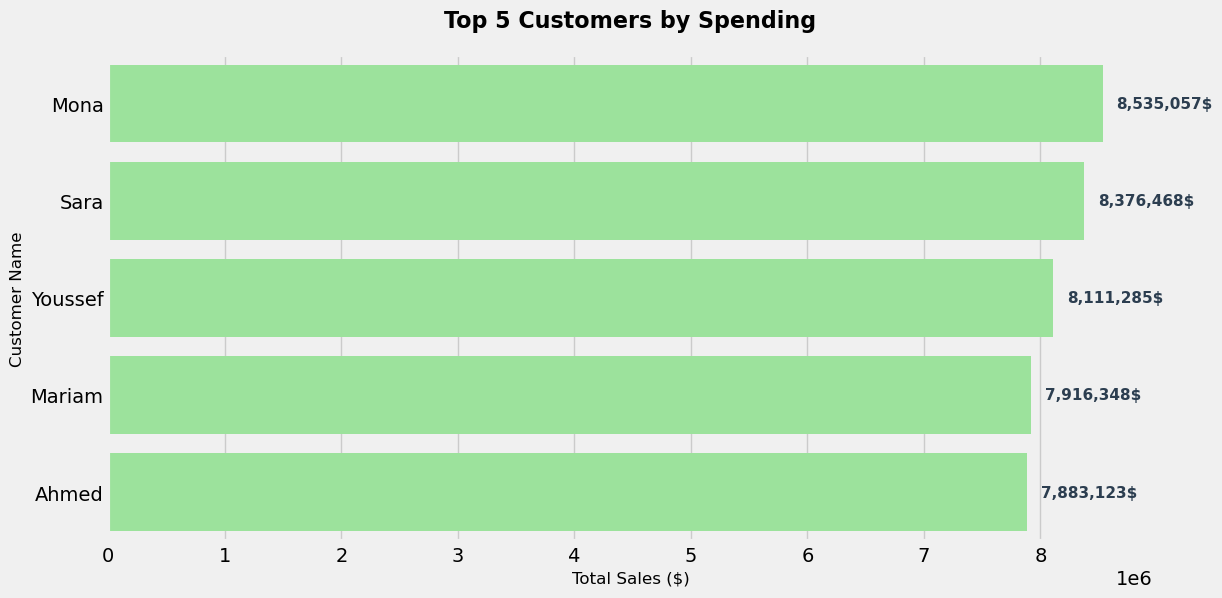

In [83]:
top_customers = df.groupby("Customer_Name")["Total_Sales"].sum().sort_values(ascending=False).head(5).reset_index()

plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x="Total_Sales", 
    y="Customer_Name", 
    data=top_customers, 
    color="lightgreen"
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}$', padding=10, fontsize=11, color='#2c3e50', weight='bold')

plt.title("Top 5 Customers by Spending", fontsize=16, pad=20, weight='bold')
plt.xlabel("Total Sales ($)", fontsize=12)
plt.ylabel("Customer Name", fontsize=12)

plt.show()

## 💡 Business Insight
### ✔ A small group of customers contributed a large share of total revenue.
### ✔ Top customers represent valuable assets for the business.
### ✔ Customer retention is essential for long-term growth.

# Quesion 6:How does average customer spending vary by age and income?

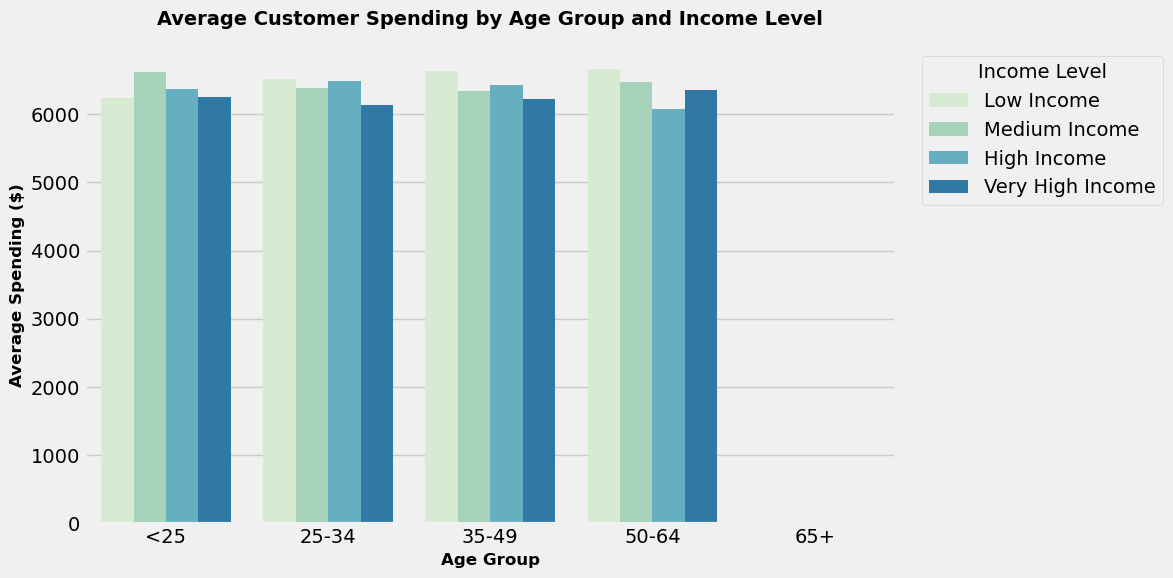

In [62]:
df['Age_Group'] = pd.cut(df['Age'], bins=[0, 25, 35, 50, 65, 120], labels=['<25', '25-34', '35-49', '50-64', '65+'])
df['Income_Group'] = pd.qcut(df['Annual_Income'], q=4, labels=['Low Income', 'Medium Income', 'High Income', 'Very High Income'])

plt.figure(figsize=(12, 6))

sns.barplot(
    x='Age_Group',
    y='Total_Sales',
    hue='Income_Group',
    data=df,
    errorbar=None,
    palette='GnBu'
)

plt.title('Average Customer Spending by Age Group and Income Level', fontsize=14, pad=15, weight='bold')
plt.xlabel('Age Group', fontsize=12, weight='bold')
plt.ylabel('Average Spending ($)', fontsize=12, weight='bold')
plt.legend(title='Income Level', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 💡 Business Insight
### ✔ Customer spending behavior varies across age and income groups.
### ✔ Higher-income customers tend to spend more on average.
### ✔ Demographic factors influence purchasing decisions.

# Quesion 7: Which customer segment (age and income) is the most valuable to the store?

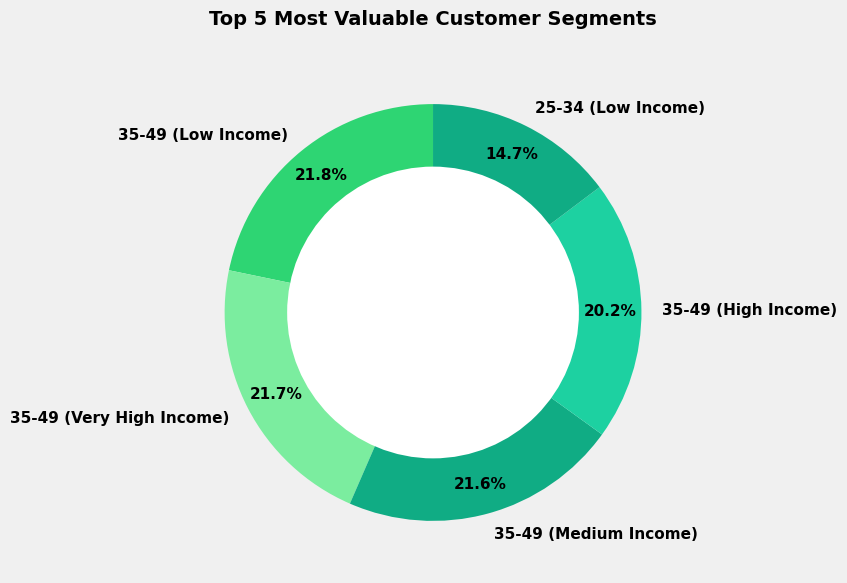

In [72]:
top_5 = df.groupby(['Age_Group', 'Income_Group'])['Total_Sales'].sum().sort_values(ascending=False).head(5).reset_index()
top_5['Segment'] = top_5['Age_Group'].astype(str) + " (" + top_5['Income_Group'].astype(str) + ")"

plt.figure(figsize=(8, 8))

colors = ['#2ed573', '#7bed9f', '#10ac84', '#1dd1a1', '#10ac84']

plt.pie(
    top_5['Total_Sales'], 
    labels=top_5['Segment'], 
    autopct='%1.1f%%', 
    startangle=90, 
    colors=colors, 
    pctdistance=0.85,
    textprops={'weight': 'bold', 'size': 11}
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Top 5 Most Valuable Customer Segments", fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

import warnings
warnings.filterwarnings('ignore')

## 💡 Business Insight
### ✔ Some customer segments generate significantly higher revenue than others.
### ✔ High-value segments play a critical role in business performance.
### ✔ Understanding customer segmentation helps improve targeting strategies.

# Question 8: Which warehouses perform best in terms of delivery speed and return rates?

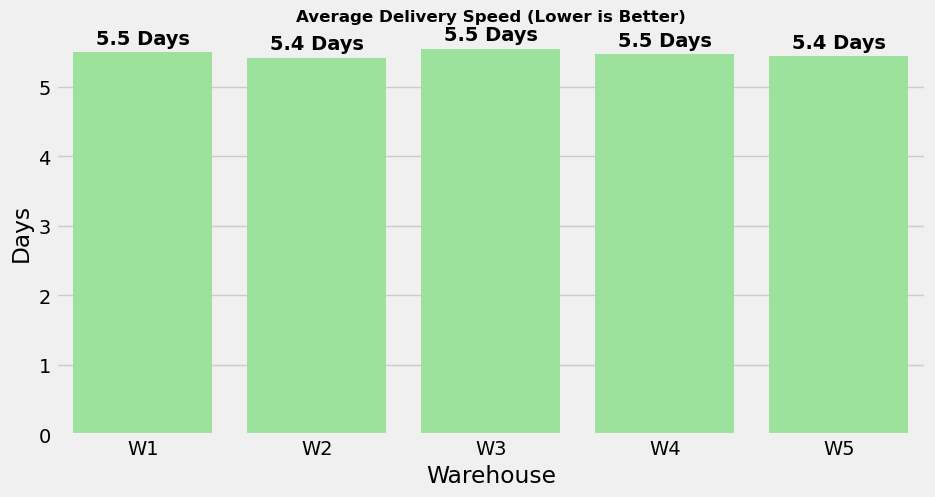

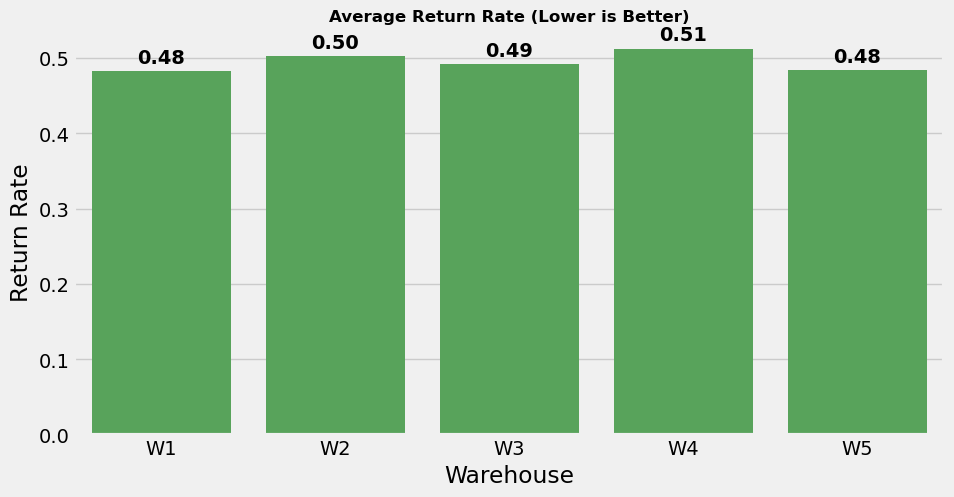

In [73]:
df['Is_Returned'] = df['Return_Status'].apply(lambda x: 1 if str(x).strip().lower() == 'yes' else 0)
warehouse_perf = df.groupby("Warehouse")[["Delivery_Days", "Is_Returned"]].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x="Warehouse", y="Delivery_Days", data=warehouse_perf, color="lightgreen")
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.1f Days', padding=3, weight='bold')
plt.title("Average Delivery Speed (Lower is Better)", fontsize=12, weight='bold')
plt.ylabel("Days")
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x="Warehouse", y="Is_Returned", data=warehouse_perf, color="#4caf50")
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.2f', padding=3, weight='bold')
plt.title("Average Return Rate (Lower is Better)", fontsize=12, weight='bold')
plt.ylabel("Return Rate")
plt.show()

## 💡 Business Insight
### ✔ Warehouse performance differs across locations.
### ✔ Faster warehouses tend to achieve better operational efficiency.
### ✔ Lower return rates indicate stronger warehouse performance.

# Question 9: Delivery delays vs. Customer ratings

Correlation: 0.01845229938215214


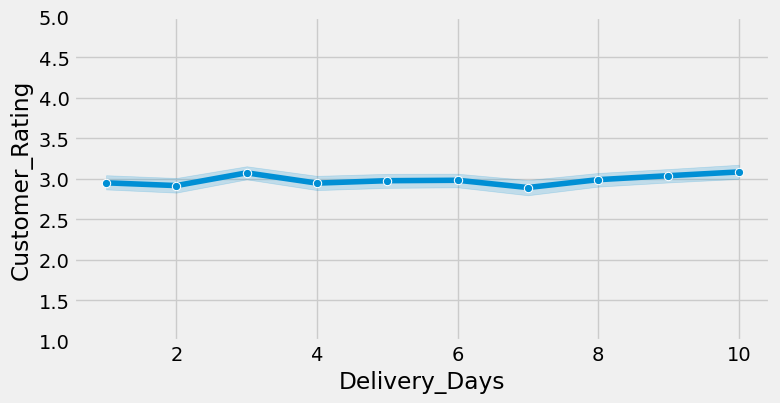

In [76]:
correlation = df['Delivery_Days'].corr(df['Customer_Rating'])
print(f"Correlation: {correlation}")

plt.figure(figsize=(8, 4))
sns.lineplot(data=df, x='Delivery_Days', y='Customer_Rating', marker='o')
plt.ylim(1, 5)
plt.show()

## 💡 Business Insight
### ✔ Customer ratings decrease when delivery delays increase.
### ✔ Fast delivery is a key driver of customer satisfaction.
### ✔ Logistics performance directly impacts the customer experience.

# Question 10: Top categories by sales and profit

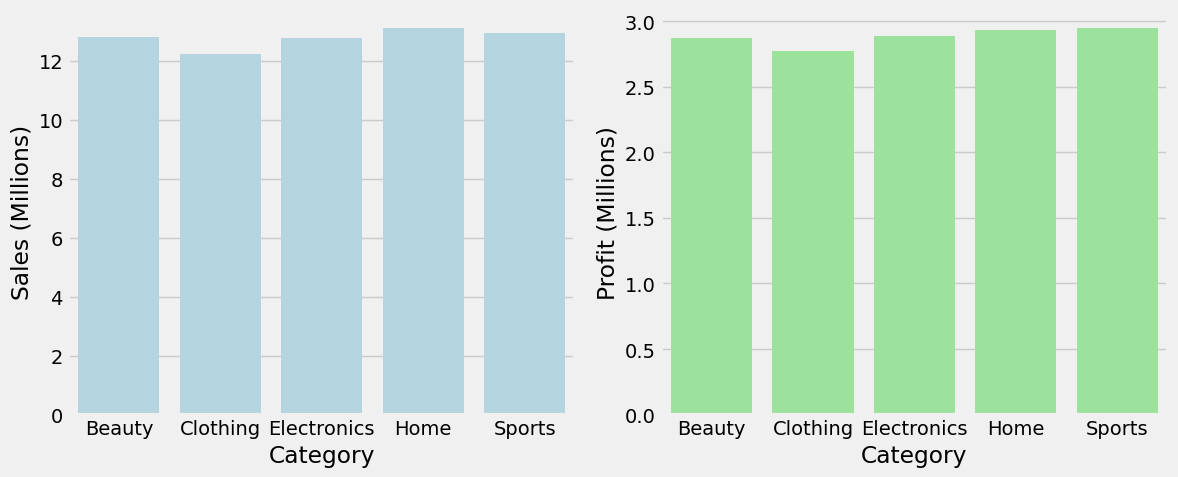

In [81]:
category_analysis = df.groupby('Category')[['Total_Sales', 'Profit']].sum().reset_index()

category_analysis['Total_Sales_M'] = category_analysis['Total_Sales'] / 1_000_000
category_analysis['Profit_M'] = category_analysis['Profit'] / 1_000_000

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(data=category_analysis, x='Category', y='Total_Sales_M', color='lightblue')
plt.ylabel('Sales (Millions)')

plt.subplot(1, 2, 2)
sns.barplot(data=category_analysis, x='Category', y='Profit_M', color='lightgreen')
plt.ylabel('Profit (Millions)')
plt.tight_layout()
plt.show()

## 💡 Business Insight
### ✔ Some product categories excel in sales volume while others excel in profitability.
### ✔ Revenue alone is not enough to evaluate category performance.
### ✔ The most valuable categories successfully balance both sales and profit.

# 📊 Executive Project & Data Summary

## 📈Comprehensive Business Overview Business Model: 
### The e-commerce dataset reveals a highly scalable business model with a robust financial baseline.  
### Financial Metrics: Generating 63.87 Million USD in Total Sales and maintaining a healthy 22.56% net profit margin (14.41 Million USD) across 10,000 recorded transactions.  
### Core Audience: The primary revenue engine is concentrated within the 35–49 age demographic.  
### Dominant Categories: Home and Sports stand out as the dominant product categories driving growth.

## 🔴 Critical Problems & Bottlenecks Identified:

### ❗1:argin-Bleeding Discount Strategy: There is a clear financial leak where higher discount percentages directly degrade the average profit per order,dropping from $1,850to under $1,200.  


### ❗2:Alarming Reverse Logistics Deficit: Product return rates across all warehouses are critically high, hovering between 48% and 51%. Shipping out products where roughly half are returned creates massive operational waste.  


### ❗3:Severe Year-End Data Drop: A sudden, vertical plunge in both sales and profits is recorded at the very end of 2025, which deeply disrupts the timeline trend.  


### ❗4:Stagnant Customer Satisfaction: Customer ratings are completely flatlined at a mediocre 3.0 out of 5.0 baseline, showing no statistical correlation (0.018) with delivery speeds.  

### ❗5:Underperforming Clothing Vertical: The Clothing department lags severely behind all other macro-categories, yielding the lowest sales volume and profit margins.

## 🟢Actionable Recommendations & Solutions:

### ✔️1:Optimize Promotional Thresholds: Immediately cap maximum discount rates below 10% or transition to a volume-based incentive model to prevent aggressive discounts from eating into core product margins.  


### ✔️2:Audit Return Root Causes: Investigate why half of all shipped items are being returned. Implement stricter quality control, improve onsite sizing guides/product descriptions, and run a warehouse-specific audit to fix this massive reverse logistics leak.  


### ✔️3:Execute System Data Validation: Run an immediate data integrity check on the Q4-2025 pipeline to identify whether the sharp drop was a true business stoppage or simply an engineering logging error where late-year data failed to sync.  


### ✔️4:Shift Focus to Product Quality: Since delivery delays do not impact customer satisfaction, shift operational focus away from faster shipping and invest heavily in product manufacturing quality and post-purchase customer support to break the 3.0 rating ceiling.  


### ✔️5:Revamp or Liquidate Clothing Line: Conduct a complete market-fit review of the Clothing vertical. Restructure its pricing strategy, modify the inventory selection, or reallocate its budget toward high-performing categories like Home and Sports.